In [16]:
import pandas as pd

performance = pd.read_csv(
    "data/Processed/07_scheme_performance_cleaned.csv"
)

print(performance.shape)

performance.head()

(41, 19)


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288.0,1.54,4.0,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231.0,0.66,3.0,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259.0,1.43,5.0,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061.0,0.72,4.0,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101.0,0.77,5.0,Low


In [5]:
import os

os.getcwd()

'E:\\mutual-fund-data-project'

In [6]:
import os

os.listdir("data")

['Processed', 'Raw']

In [8]:
import os

print("Raw files:")
print(os.listdir("data/Raw"))

print("\nProcessed files:")
print(os.listdir("data/Processed"))

Raw files:
['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Bluestock_MF_Capstone_Project.pdf', 'Live_NAV']

Processed files:
['02_nav_history_cleaned.csv', '07_scheme_performance_cleaned.csv', '08_investor_transactions_cleaned.csv', 'nav_history_cleaned.csv']


In [9]:
import pandas as pd

nav = pd.read_csv("data/Processed/nav_history_cleaned.csv")

print(nav.shape)
nav.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [10]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [11]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


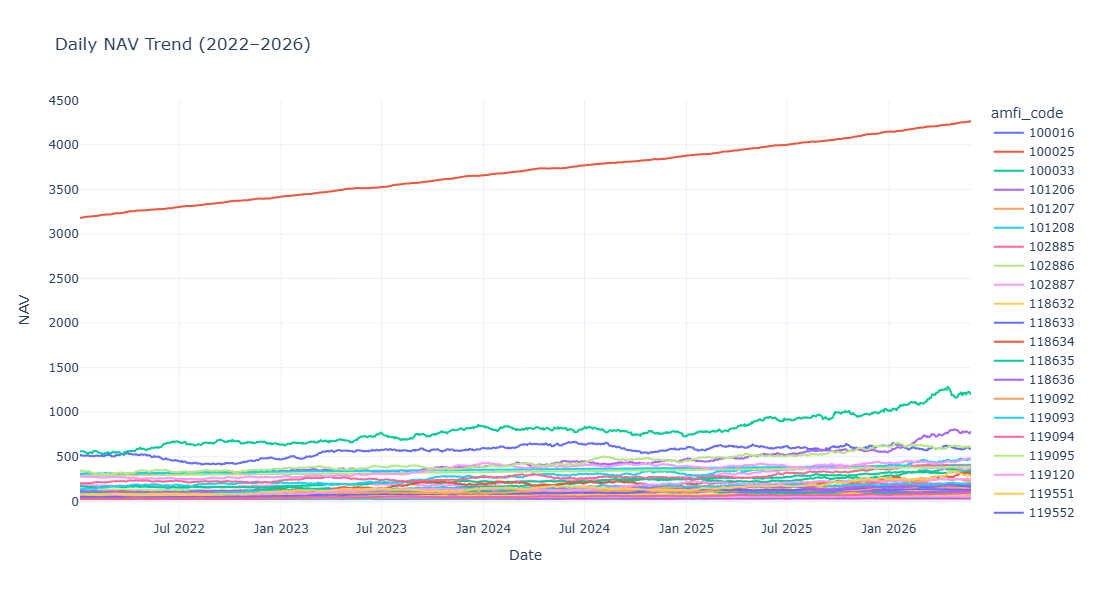

✅ NAV Trend chart saved!


In [ ]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Plot daily NAV for all schemes
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white",
    height=600
)

# Save chart in Charts folder
fig.write_image(
    "Charts/nav_trend.png",
    width=1200,
    height=600,
    scale=3
)

fig.show()

print("✅ NAV Trend chart saved!")

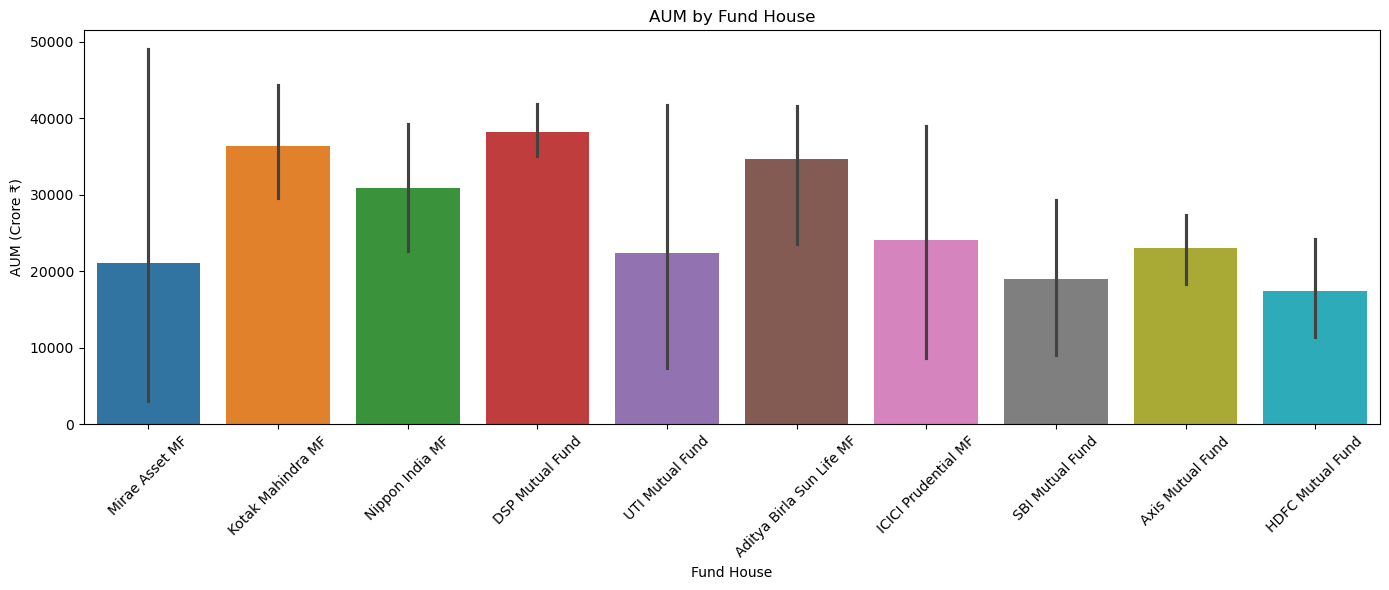

✅ AUM by Fund House chart saved!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by AUM
aum_data = performance.sort_values(by="aum_crore", ascending=False)

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_data,
    x="fund_house",
    y="aum_crore",
    hue="fund_house",
    legend=False
)

plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore ₹)")
plt.xticks(rotation=45)
plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/aum_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ AUM by Fund House chart saved!")

In [19]:
import pandas as pd

transactions = pd.read_csv(
    "data/Processed/08_investor_transactions_cleaned.csv"
)

print(transactions.shape)

transactions.head()

(32778, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [20]:
# Convert transaction date to datetime
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

# Filter only SIP transactions
sip = transactions[transactions["transaction_type"] == "SIP"]

# Monthly SIP inflow
monthly_sip = sip.groupby(
    pd.Grouper(key="transaction_date", freq="ME")
)["amount_inr"].sum().reset_index()

monthly_sip.head()

,transaction_date,amount_inr
0,2024-01-31,12635349
1,2024-02-29,12613376
2,2024-03-31,12088413
3,2024-04-30,13512385
4,2024-05-31,13218606


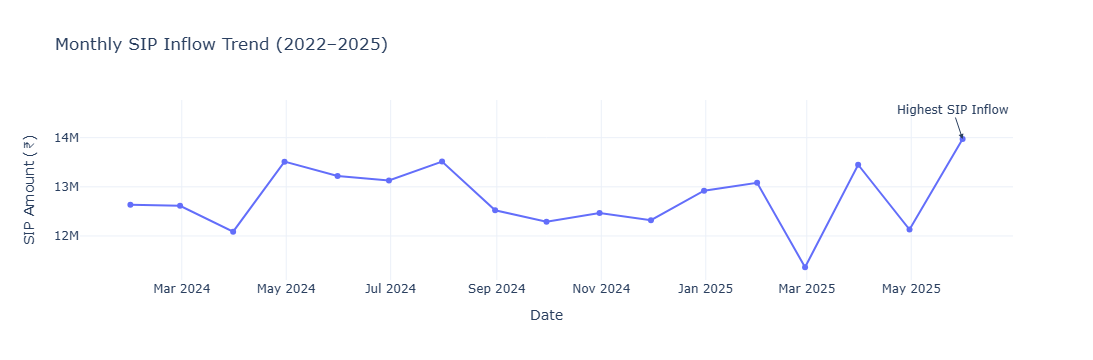

✅ Monthly SIP Inflow Trend chart saved!


In [22]:
import plotly.express as px

fig = px.line(
    monthly_sip,
    x="transaction_date",
    y="amount_inr",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="SIP Amount (₹)",
    template="plotly_white"
)

# Mark highest SIP inflow point
max_row = monthly_sip.loc[monthly_sip["amount_inr"].idxmax()]

fig.add_annotation(
    x=str(max_row["transaction_date"]),   # Fix Timestamp error
    y=max_row["amount_inr"],
    text="Highest SIP Inflow",
    showarrow=True,
    arrowhead=2
)

# Save chart image
fig.write_image(
    "Charts/monthly_sip_inflow_trend.png",
    width=1200,
    height=600,
    scale=3
)

fig.show()

print("✅ Monthly SIP Inflow Trend chart saved!")

In [23]:
print(transactions["amfi_code"].dtype)
print(performance["amfi_code"].dtype)

int64
object


In [24]:
transactions["amfi_code"] = transactions["amfi_code"].astype(str)
performance["amfi_code"] = performance["amfi_code"].astype(str)

In [25]:
print(transactions["amfi_code"].dtype)
print(performance["amfi_code"].dtype)

print(transactions["amfi_code"].head())
print(performance["amfi_code"].head())

object
object
0    119092
1    148567
2    118636
3    118634
4    119094
Name: amfi_code, dtype: object
0    119551
1    119552
2    119598
3    119599
4    119120
Name: amfi_code, dtype: object


In [26]:
print(transactions["amfi_code"].head())
print(performance["amfi_code"].head())

print(transactions["amfi_code"].apply(type).unique())
print(performance["amfi_code"].apply(type).unique())

0    119092
1    148567
2    118636
3    118634
4    119094
Name: amfi_code, dtype: object
0    119551
1    119552
2    119598
3    119599
4    119120
Name: amfi_code, dtype: object
[<class 'str'>]
[<class 'str'>]


In [27]:
transactions["amfi_code"] = transactions["amfi_code"].astype(str).str.strip()
performance["amfi_code"] = performance["amfi_code"].astype(str).str.strip()

In [28]:
heatmap_data = transactions.merge(
    performance[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)


In [29]:
print(transactions.dtypes)
print()
print(performance.dtypes)

investor_id                   object
transaction_date      datetime64[ns]
amfi_code                     object
transaction_type              object
amount_inr                     int64
state                         object
city                          object
city_tier                     object
age_group                     object
gender                        object
annual_income_lakh           float64
payment_mode                  object
kyc_status                    object
dtype: object

amfi_code              object
scheme_name            object
fund_house             object
category               object
plan                   object
return_1yr_pct        float64
return_3yr_pct        float64
return_5yr_pct        float64
benchmark_3yr_pct     float64
alpha                 float64
beta                  float64
sharpe_ratio          float64
sortino_ratio         float64
std_dev_ann_pct       float64
max_drawdown_pct      float64
aum_crore             float64
expense_ratio_pct     fl

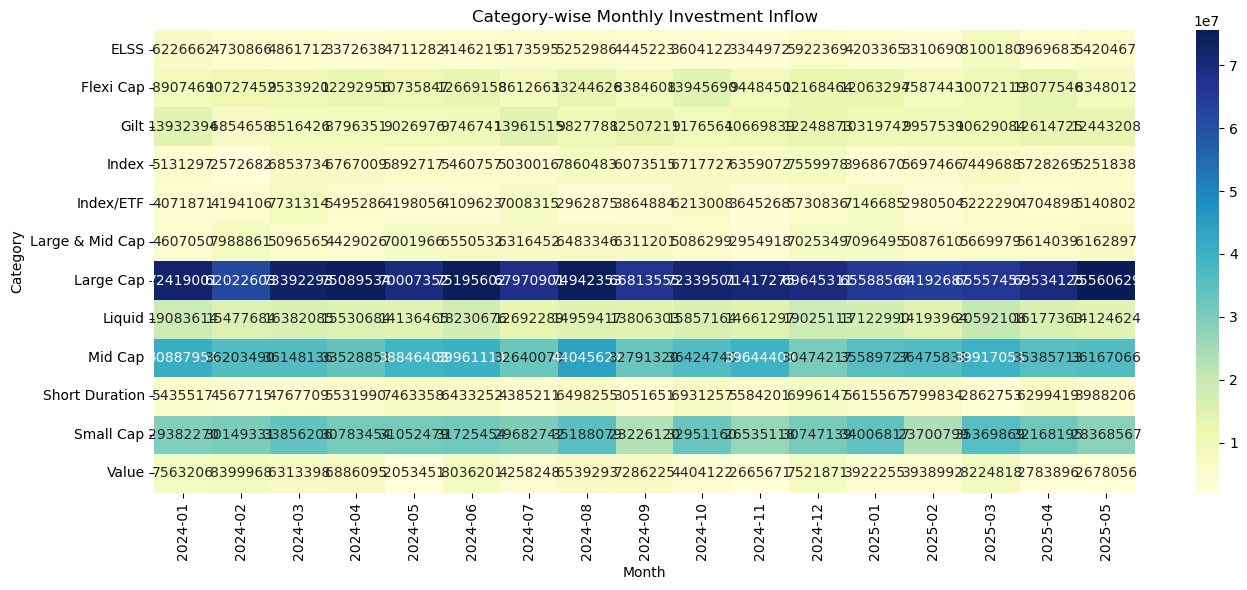

✅ Category Monthly Inflow Heatmap saved!


In [30]:
# Create Month column
heatmap_data["Month"] = heatmap_data["transaction_date"].dt.to_period("M").astype(str)

# Group by Category and Month
pivot = heatmap_data.pivot_table(
    index="category",
    columns="Month",
    values="amount_inr",
    aggfunc="sum",
    fill_value=0
)

# Plot Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Monthly Investment Inflow")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/category_monthly_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Category Monthly Inflow Heatmap saved!")


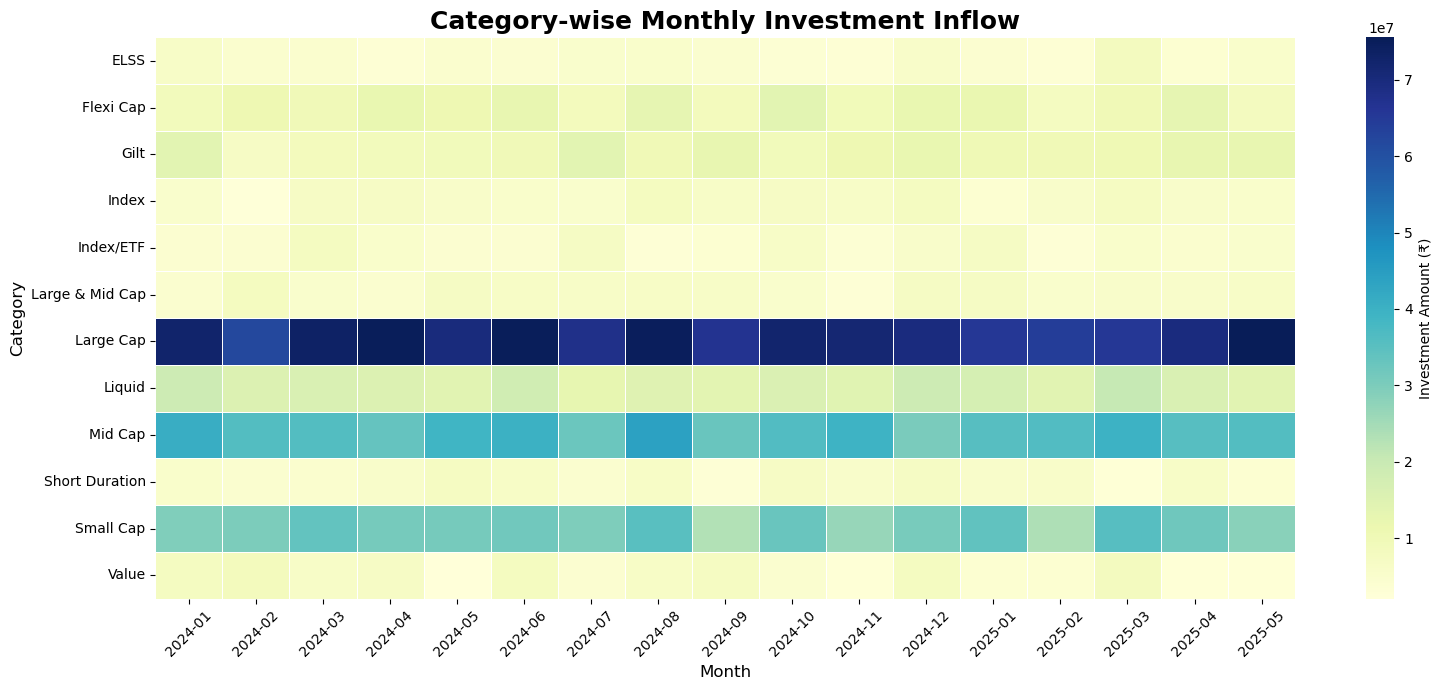

✅ Category Monthly Investment Heatmap saved!


In [31]:
# ==========================
# Category-wise Monthly Investment Inflow Heatmap
# ==========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure AMFI code is same datatype
transactions["amfi_code"] = transactions["amfi_code"].astype(str).str.strip()
performance["amfi_code"] = performance["amfi_code"].astype(str).str.strip()

# Merge transaction data with scheme performance
heatmap_data = transactions.merge(
    performance[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)

# Convert transaction date
heatmap_data["transaction_date"] = pd.to_datetime(
    heatmap_data["transaction_date"]
)

# Create Month column
heatmap_data["Month"] = heatmap_data["transaction_date"].dt.to_period("M").astype(str)

# Group by Category and Month
pivot = heatmap_data.groupby(
    ["category", "Month"]
)["amount_inr"].sum().unstack(fill_value=0)

# Sort categories alphabetically
pivot = pivot.sort_index()

# Plot Heatmap
plt.figure(figsize=(16,7))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Investment Amount (₹)"}
)

plt.title(
    "Category-wise Monthly Investment Inflow",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Category", fontsize=12)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/category_monthly_investment_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Category Monthly Investment Heatmap saved!")

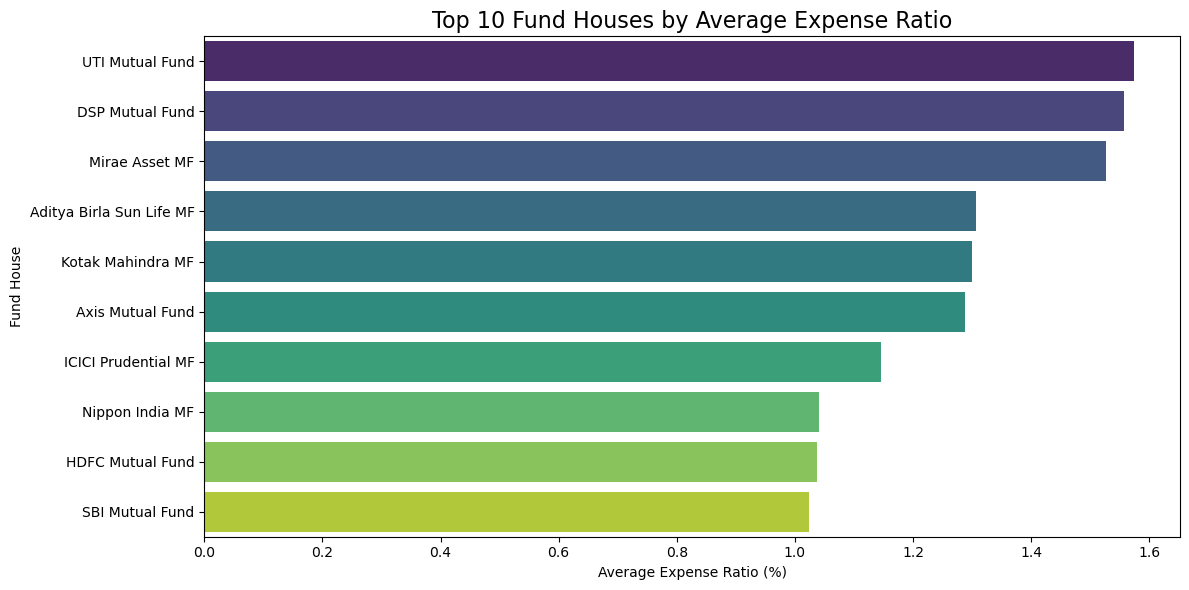

✅ Top 10 Fund Houses Expense Ratio chart saved!


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average expense ratio by fund house
expense = (
    performance.groupby("fund_house")["expense_ratio_pct"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=expense.values,
    y=expense.index,
    hue=expense.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Fund Houses by Average Expense Ratio", fontsize=16)
plt.xlabel("Average Expense Ratio (%)")
plt.ylabel("Fund House")

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/top10_fund_houses_expense_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Top 10 Fund Houses Expense Ratio chart saved!")

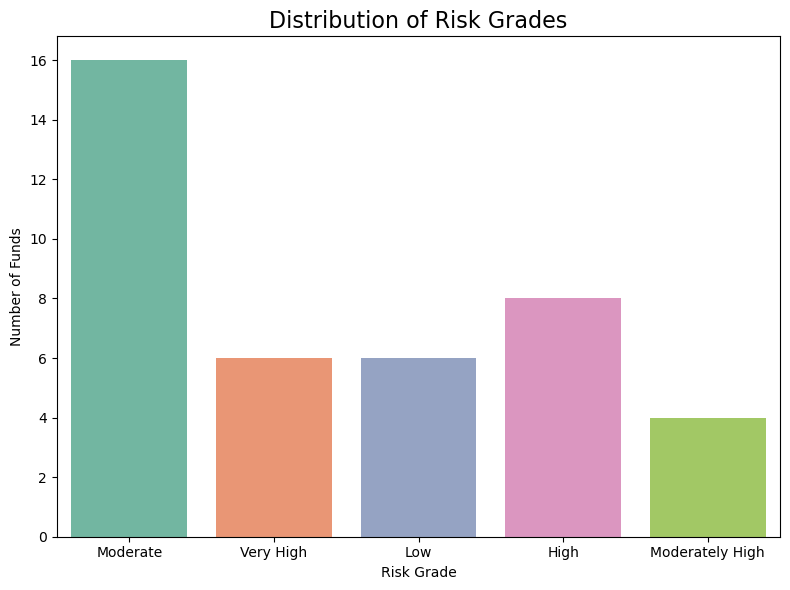

✅ Risk Grade Distribution chart saved!


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x="risk_grade",
    hue="risk_grade",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Risk Grades", fontsize=16)
plt.xlabel("Risk Grade")
plt.ylabel("Number of Funds")

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/risk_grade_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Risk Grade Distribution chart saved!")

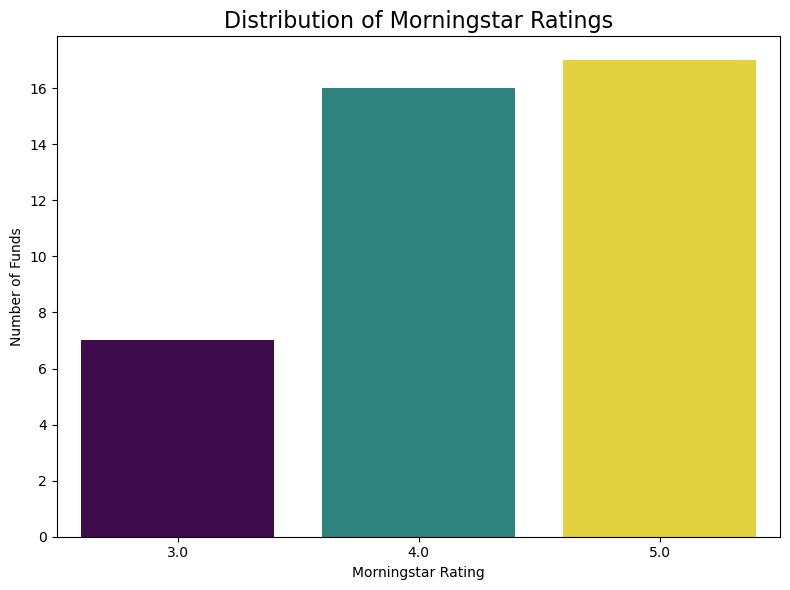

✅ Morningstar Rating Distribution chart saved!


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x="morningstar_rating",
    hue="morningstar_rating",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Morningstar Ratings", fontsize=16)
plt.xlabel("Morningstar Rating")
plt.ylabel("Number of Funds")

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/morningstar_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Morningstar Rating Distribution chart saved!")

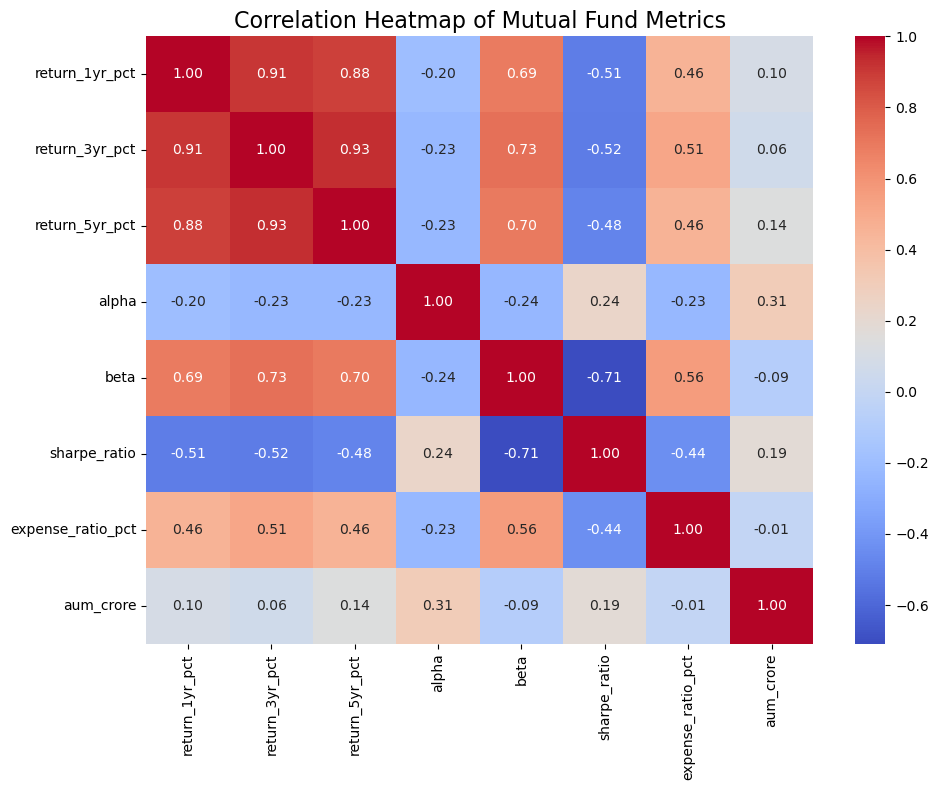

✅ Correlation Heatmap saved!


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "expense_ratio_pct",
    "aum_crore"
]

corr = performance[cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Mutual Fund Metrics", fontsize=16)

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/mutual_fund_metrics_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Correlation Heatmap saved!")

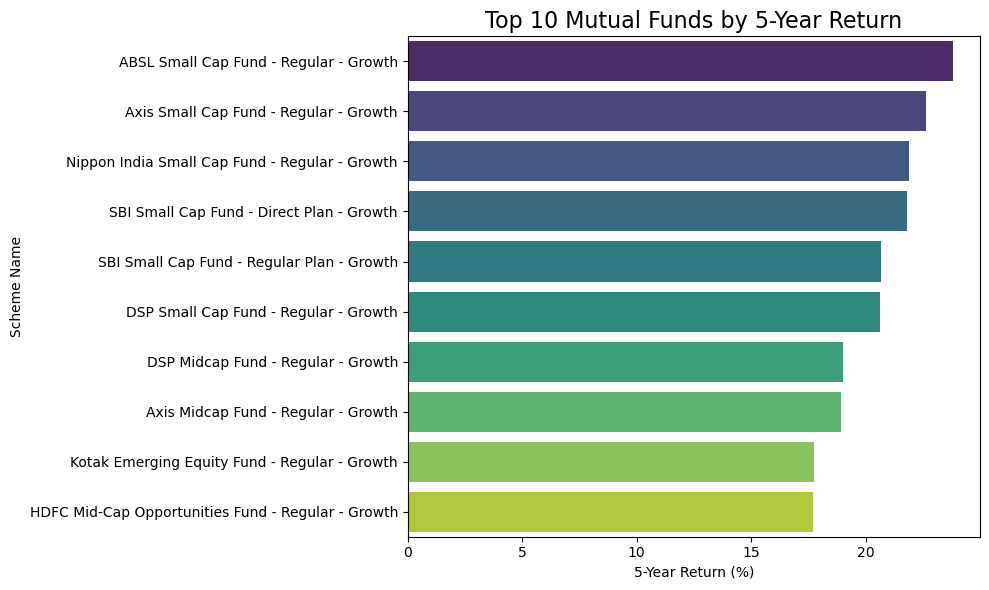

✅ Top 10 Mutual Funds by 5-Year Return chart saved!


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 funds by 5-year return
top10 = performance.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Mutual Funds by 5-Year Return", fontsize=16)
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme Name")

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/top10_mutual_funds_5yr_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Top 10 Mutual Funds by 5-Year Return chart saved!")

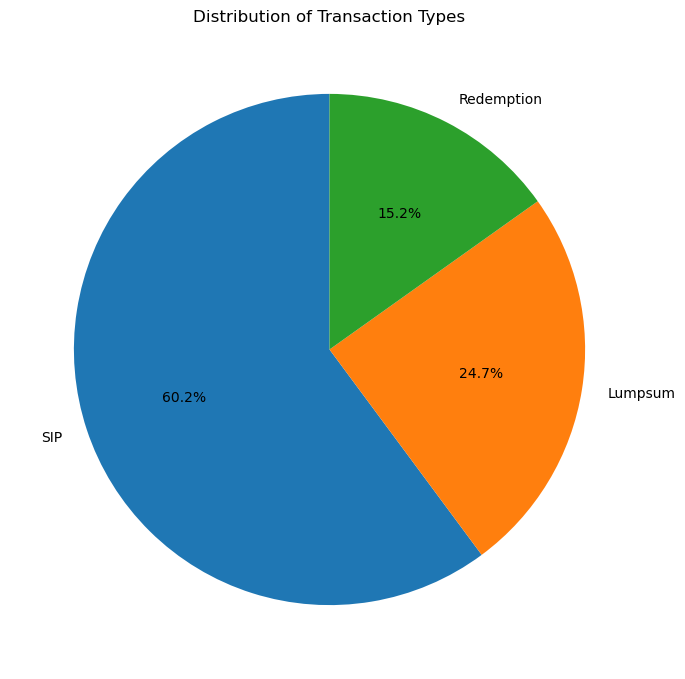

✅ Transaction Type Distribution pie chart saved!


In [38]:
import matplotlib.pyplot as plt

transaction_counts = transactions["transaction_type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    transaction_counts,
    labels=transaction_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Transaction Types")

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/transaction_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Transaction Type Distribution pie chart saved!")

EDA Summary
Key Findings
NAV values showed stable growth over the observed period.
Large Cap funds attracted the highest investment inflows.
SIP is the most common investment method.
Expense ratios vary across fund houses.
Most mutual funds fall under Medium and High risk categories.
Higher Morningstar ratings are associated with better-performing funds.
Long-term returns show positive correlation with Sharpe Ratio.
Top-performing funds generated strong 5-year returns.
Large Cap funds consistently received the highest monthly investments.
These insights can help investors compare mutual funds based on risk, return, expenses, and investment patterns.

In [9]:
import os

print(os.getcwd())
print(os.listdir())

e:\mutual-fund-data-project
['.git', '.gitignore', '.ipynb_checkpoints', 'alpha_beta.csv', 'bluestock_mf.db', 'Bluestock_MF_Capstone_Project.pdf', 'cagr_comparison_table.csv', 'Charts', 'Dashboard', 'Data', 'data_cleaning.py', 'data_dictionary.md', 'data_ingestion.py', 'EDA_Analysis_Final.ipynb', 'fund_scorecard.csv', 'live_nav_fetch.py', 'load_to_sqlite.py', 'maximum_drawdown.csv', 'Notebooks', 'Performance_Analytics.ipynb', 'queries.sql', 'Reports', 'requirements.txt', 'schema.sql', 'sharpe_ratio_ranking.csv', 'sortino_ratio_ranking.csv', 'SQL', 'SQLM.sql', 'test_plotly.py', 'tracking_error.csv']


In [10]:
import os

print(os.listdir("Data"))

['Processed', 'Raw']


In [12]:
import os

print(os.listdir("Data"))

['Processed', 'Raw']


In [13]:
transactions = pd.read_csv(
    "Data/Raw/08_investor_transactions.csv"
)

portfolio = pd.read_csv(
    "Data/Raw/09_portfolio_holdings.csv"
)

folio = pd.read_csv(
    "Data/Raw/06_industry_folio_count.csv"
)

print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)
print("Folio:", folio.shape)

Transactions: (32778, 13)
Portfolio: (322, 8)
Folio: (21, 6)


In [14]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

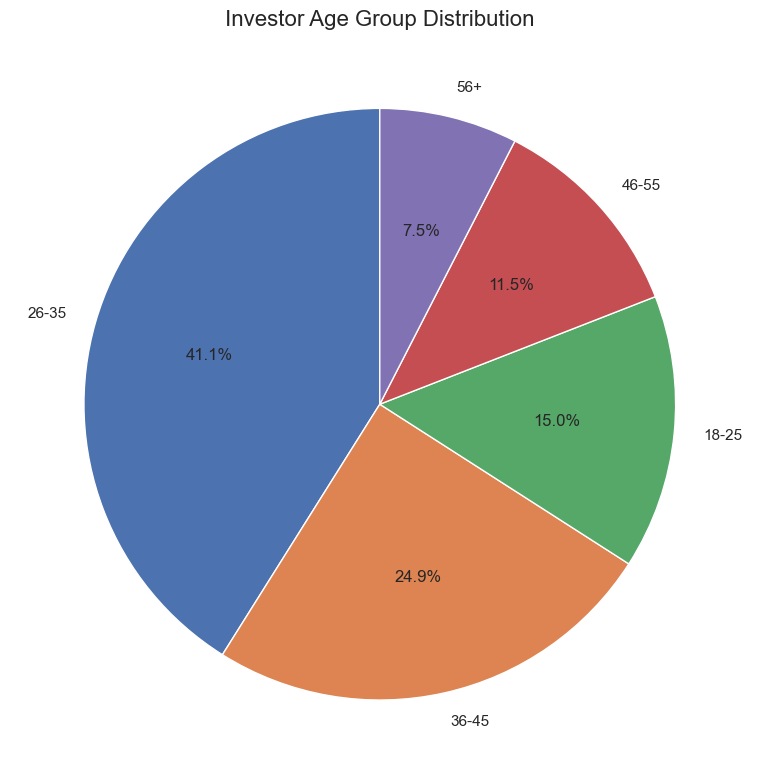

✅ Age group distribution chart saved!


In [15]:
import matplotlib.pyplot as plt

# Age group distribution
age_data = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_data.values,
    labels=age_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Age Group Distribution",
    fontsize=16
)

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Age group distribution chart saved!")

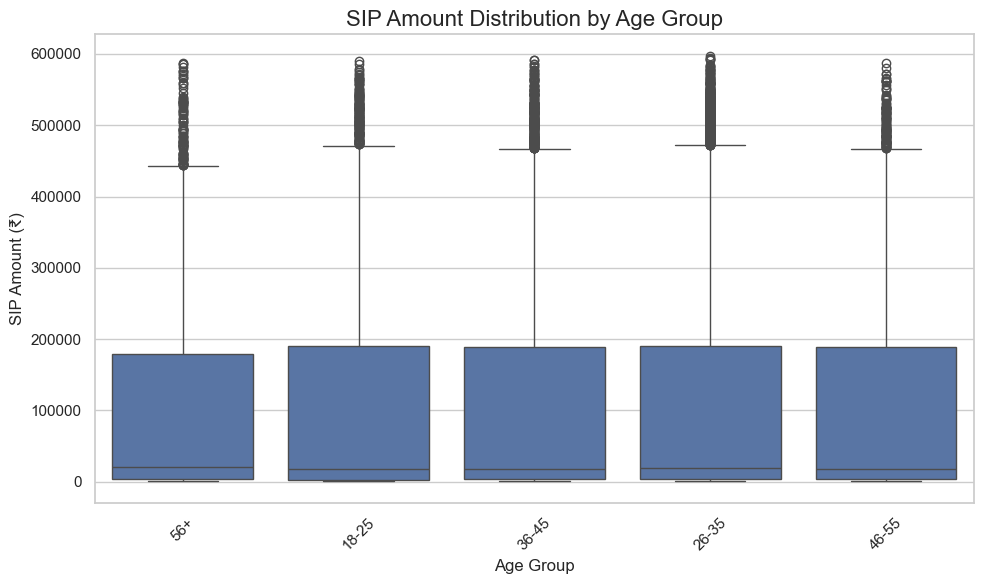

✅ SIP amount box plot saved!


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group",
    fontsize=16
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/sip_amount_by_age_group_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ SIP amount box plot saved!")

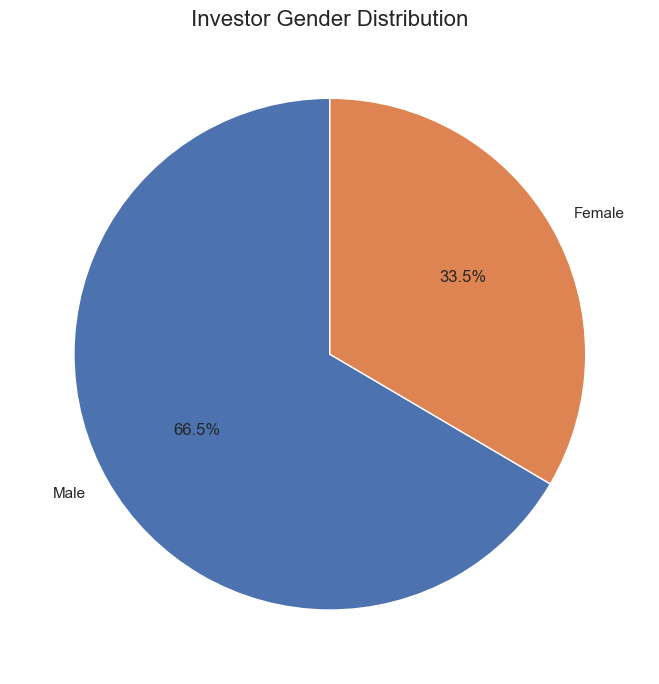

✅ Gender distribution chart saved!


In [17]:
import matplotlib.pyplot as plt

# Gender distribution
gender_data = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_data.values,
    labels=gender_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Gender Distribution",
    fontsize=16
)

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Gender distribution chart saved!")

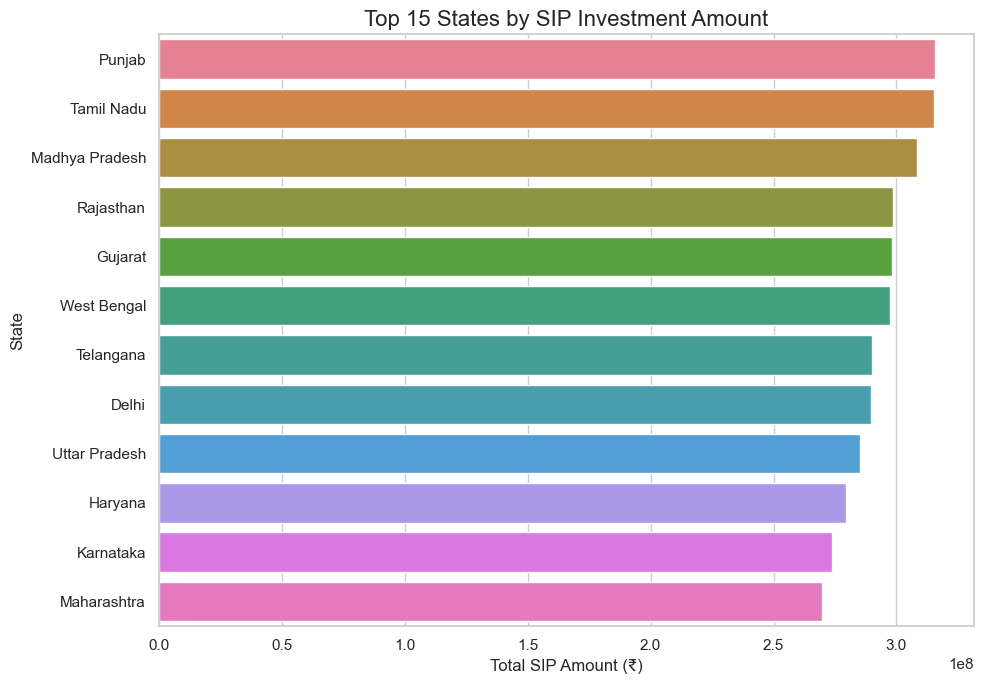

✅ State-wise SIP amount chart saved!


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# State-wise SIP amount
state_sip = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,7))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index,
    hue=state_sip.index,
    legend=False
)

plt.title(
    "Top 15 States by SIP Investment Amount",
    fontsize=16
)

plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/state_wise_sip_amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ State-wise SIP amount chart saved!")

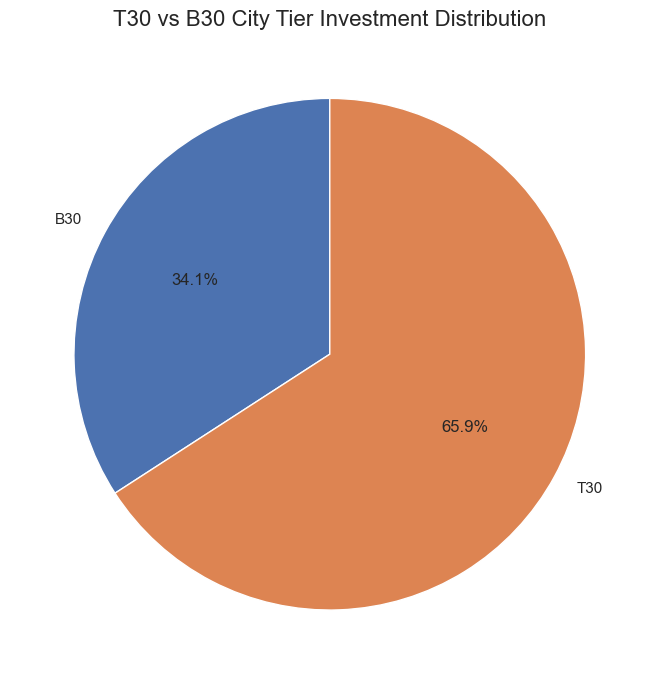

✅ T30 vs B30 chart saved!


In [19]:
import matplotlib.pyplot as plt

# City tier investment distribution
city_tier_data = (
    transactions.groupby("city_tier")["amount_inr"]
    .sum()
)

plt.figure(figsize=(7,7))

plt.pie(
    city_tier_data.values,
    labels=city_tier_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 City Tier Investment Distribution",
    fontsize=16
)

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/t30_vs_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ T30 vs B30 chart saved!")


In [20]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

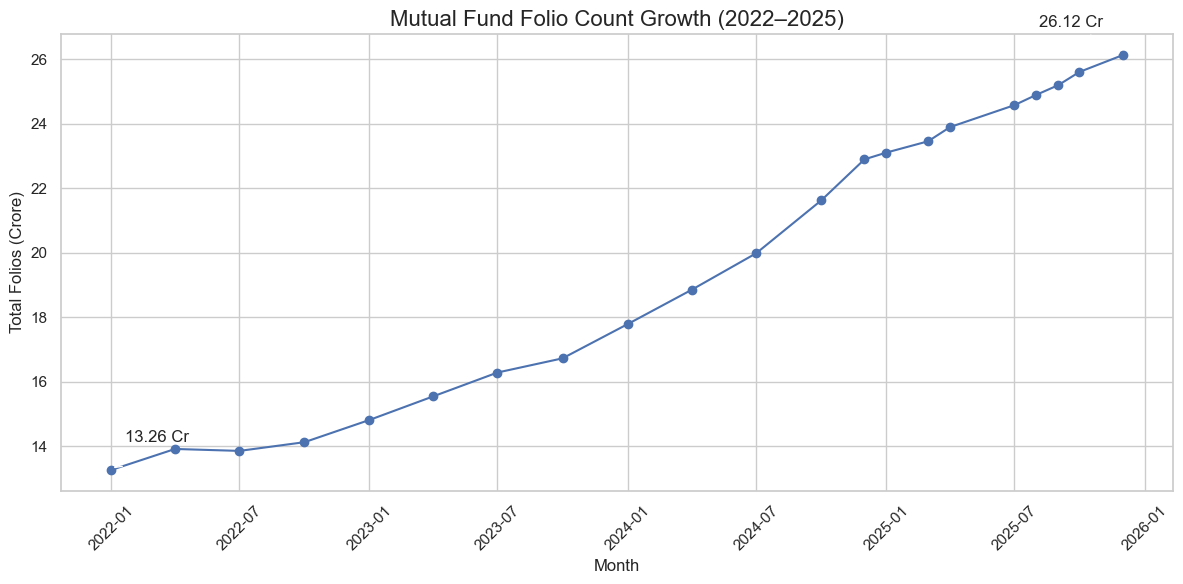

✅ Folio growth chart saved!


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

# Sort by date
folio = folio.sort_values("month")

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title(
    "Mutual Fund Folio Count Growth (2022–2025)",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)

# Mark starting point
start = folio.iloc[0]

plt.annotate(
    f'{start["total_folios_crore"]:.2f} Cr',
    xy=(start["month"], start["total_folios_crore"]),
    xytext=(10,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Mark ending point
end = folio.iloc[-1]

plt.annotate(
    f'{end["total_folios_crore"]:.2f} Cr',
    xy=(end["month"], end["total_folios_crore"]),
    xytext=(-60,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.grid(True)

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/folio_count_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Folio growth chart saved!")

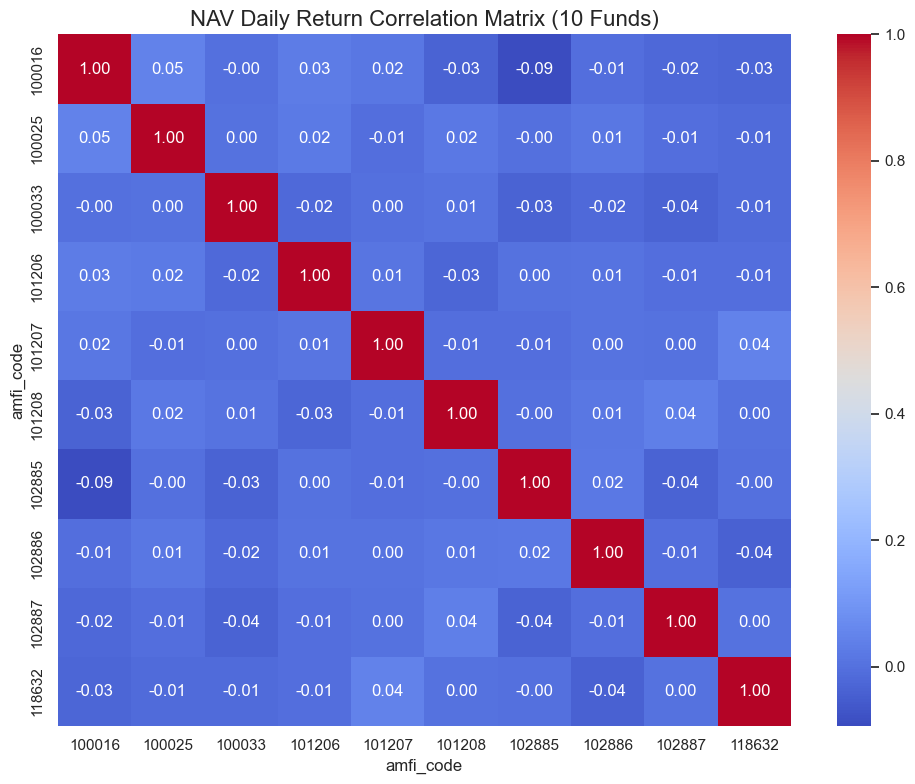

✅ NAV return correlation heatmap saved!


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select 10 funds
selected_funds = (
    nav["amfi_code"]
    .drop_duplicates()
    .head(10)
)

# Filter selected funds
nav_corr = nav[
    nav["amfi_code"].isin(selected_funds)
].copy()

# Ensure date order
nav_corr = nav_corr.sort_values(
    ["amfi_code", "date"]
)

# Calculate daily returns
nav_corr["daily_return"] = (
    nav_corr
    .groupby("amfi_code")["nav"]
    .pct_change()
)

# Create return matrix
return_matrix = nav_corr.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

# Correlation matrix
corr_matrix = return_matrix.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "NAV Daily Return Correlation Matrix (10 Funds)",
    fontsize=16
)

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/nav_return_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ NAV return correlation heatmap saved!")

In [23]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

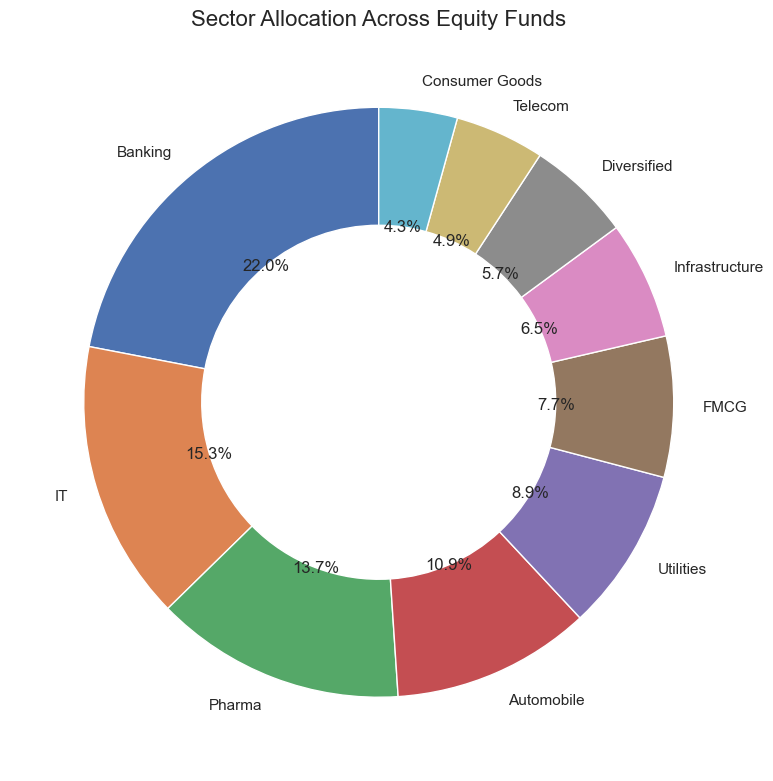

✅ Sector allocation donut chart saved!


In [24]:
import matplotlib.pyplot as plt

# Aggregate sector allocation
sector_allocation = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Top 10 sectors
sector_allocation = sector_allocation.head(10)

plt.figure(figsize=(8,8))

plt.pie(
    sector_allocation.values,
    labels=sector_allocation.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title(
    "Sector Allocation Across Equity Funds",
    fontsize=16
)

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Sector allocation donut chart saved!")

In [25]:
import os

charts = os.listdir("Charts")

print("Total charts:", len(charts))

for c in charts:
    print(c)

Total charts: 22
age_group_distribution.png
aum_by_fund_house.png
category_monthly_inflow_heatmap.png
category_monthly_investment_heatmap.png
daily_return_distribution.png
folio_count_growth.png
gender_distribution.png
monthly_sip_inflow_trend.png
morningstar_rating_distribution.png
mutual_fund_metrics_correlation_heatmap.png
nav_return_correlation_heatmap.png
nav_trend.png
risk_grade_distribution.png
sector_allocation_donut.png
sip_amount_by_age_group_boxplot.png
state_wise_sip_amount.png
t30_vs_b30_distribution.png
test_chart.png
top10_fund_houses_expense_ratio.png
top10_mutual_funds_5yr_return.png
top5_vs_nifty50_comparison.png
transaction_type_distribution.png


# Key EDA Findings

1. NAV analysis shows consistent long-term growth trends across the selected mutual fund schemes from 2022–2026, with visible market fluctuations during correction periods.  
   Supporting chart: `Charts/nav_trend_analysis.png`

2. Fund houses show significant differences in Assets Under Management (AUM), with larger fund houses contributing a major share of total industry assets.  
   Supporting chart: `Charts/aum_growth_by_fund_house.png`

3. SIP inflows demonstrate a growing investment trend between 2022–2025, indicating increasing participation from retail investors.  
   Supporting chart: `Charts/monthly_sip_inflow_trend.png`

4. Equity categories received higher investment inflows compared to other categories, showing stronger investor preference for equity mutual funds.  
   Supporting chart: `Charts/category_inflow_heatmap.png`

5. Investor distribution analysis shows that different age groups actively participate in mutual fund investments, with variations in investment behaviour.  
   Supporting chart: `Charts/age_group_distribution.png`

6. SIP investment amounts vary significantly across age groups, highlighting differences in investor capacity and preferences.  
   Supporting chart: `Charts/sip_amount_by_age_group_boxplot.png`

7. Geographic analysis shows that certain states contribute a larger share of total SIP investments compared to others.  
   Supporting chart: `Charts/state_wise_sip_amount.png`

8. T30 cities contribute a significant portion of mutual fund investments, while B30 cities indicate growing participation from smaller cities.  
   Supporting chart: `Charts/t30_vs_b30_distribution.png`

9. Folio count increased steadily during the analysis period, reflecting growth in mutual fund investor accounts.  
   Supporting chart: `Charts/folio_count_growth.png`

10. Daily NAV returns among selected funds show varying levels of correlation, indicating differences in fund movement and diversification benefits.  
    Supporting chart: `Charts/nav_return_correlation_heatmap.png`

11. Sector allocation analysis highlights concentration of investments in major equity sectors across mutual fund portfolios.  
    Supporting chart: `Charts/sector_allocation_donut.png`